## 1. 데이터 파일 구조 확인

AI-Hub에서 다운로드한 Training/Validation 압축파일을 확인하고,
7개 감정 클래스의 라벨링 데이터와 원천데이터가 정상적으로 확보되었는지 점검한다.

In [1]:
from pathlib import Path
import pandas as pd
import zipfile

# AI-Hub에서 다운로드한 본 데이터 폴더
download_dir = Path("../02_data/downloads")

print("폴더 존재 여부:", download_dir.exists())

폴더 존재 여부: True


In [2]:
# downloads 폴더 아래의 모든 ZIP 파일 검색
zip_files = list(download_dir.rglob("*.zip"))

print("전체 ZIP 파일 수:", len(zip_files))

전체 ZIP 파일 수: 49


In [3]:
for path in zip_files[:10]:
    print(path.name)

EMOIMG_기쁨_VALID.zip
EMOIMG_기쁨_VALID.zip
[라벨]EMOIMG_기쁨_TRAIN.zip
[라벨]EMOIMG_당황_TRAIN.zip
[라벨]EMOIMG_분노_TRAIN.zip
[라벨]EMOIMG_불안_TRAIN.zip
[라벨]EMOIMG_상처_TRAIN.zip
[라벨]EMOIMG_슬픔_TRAIN.zip
[라벨]EMOIMG_중립_TRAIN.zip
[원천]EMOIMG_기쁨_TRAIN_01.zip


In [4]:
for path in zip_files[:10]:
    print(path)

..\02_data\downloads\092.한국인 감정인식을 위한 복합 영상 데이터\01.데이터\2.Validation\라벨링데이터_231004_add\EMOIMG_기쁨_VALID.zip
..\02_data\downloads\092.한국인 감정인식을 위한 복합 영상 데이터\01.데이터\2.Validation\원천데이터_0114_add\EMOIMG_기쁨_VALID.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_기쁨_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_당황_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_분노_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_불안_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_상처_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_슬픔_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[라벨]EMOIMG_중립_TRAIN.zip
..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Training\[원천]EMOIMG_기쁨_TRAIN_01.zip


In [5]:
# ZIP 파일 정보를 DataFrame으로 정리
zip_df = pd.DataFrame({
    "file_name": [path.name for path in zip_files],
    "file_path": [str(path) for path in zip_files],
    "size_gb": [
        path.stat().st_size / (1024 ** 3)
        for path in zip_files
    ]
})

zip_df.head()

,file_name,file_path,size_gb
0,EMOIMG_기쁨_VALID.zip,..\02_data\downloads\092.한국인 감정인식을 위한 복합 영상 데이...,0.001127
1,EMOIMG_기쁨_VALID.zip,..\02_data\downloads\092.한국인 감정인식을 위한 복합 영상 데이...,13.326116
2,[라벨]EMOIMG_기쁨_TRAIN.zip,..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Traini...,0.009010
3,[라벨]EMOIMG_당황_TRAIN.zip,..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Traini...,0.009021
4,[라벨]EMOIMG_분노_TRAIN.zip,..\02_data\downloads\한국인 감정인식을 위한 복합 영상\Traini...,0.008963


In [6]:
print(f"ZIP 전체 개수: {len(zip_df)}개")
print(f"ZIP 전체 용량: {zip_df['size_gb'].sum():.2f} GB")

ZIP 전체 개수: 49개
ZIP 전체 용량: 835.61 GB


In [7]:
# 라벨링 데이터 / 원천 데이터 구분
# 일반 파일은 [라벨], [원천] 표시를 사용하고,
# 기쁨 VALID는 상위 폴더명까지 함께 확인한다.
def get_data_type(row):
    file_name = row["file_name"]
    file_path = row["file_path"]

    if "[라벨]" in file_name or "라벨링데이터" in file_path:
        return "label"

    elif "[원천]" in file_name or "원천데이터" in file_path:
        return "source"

    return "unknown"


zip_df["data_type"] = zip_df.apply(get_data_type, axis=1)

zip_df["data_type"].value_counts()

data_type
source    35
label     14
Name: count, dtype: int64

In [8]:
# Training / Validation 구분
def get_split(file_name):
    if "TRAIN" in file_name:
        return "train"
    elif "VALID" in file_name:
        return "valid"
    return "unknown"


zip_df["split"] = zip_df["file_name"].apply(get_split)

In [9]:
# 7개 감정 클래스 정의
emotions = [
    "기쁨",
    "당황",
    "분노",
    "불안",
    "상처",
    "슬픔",
    "중립"
]


# 파일명에서 감정 클래스 추출
def get_emotion(file_name):
    for emotion in emotions:
        if emotion in file_name:
            return emotion
    return None


zip_df["emotion"] = zip_df["file_name"].apply(get_emotion)

In [10]:
pd.crosstab(
    zip_df["emotion"],
    [zip_df["split"], zip_df["data_type"]]
)

split     train        valid       
data_type label source label source
emotion                            
기쁨            1      4     1      1
당황            1      4     1      1
분노            1      4     1      1
불안            1      4     1      1
상처            1      4     1      1
슬픔            1      4     1      1
중립            1      4     1      1

### 확인 결과

- 전체 ZIP 파일 수는 49개로 확인되었다.
- 7개 감정 클래스 모두 Training/Validation 라벨링 데이터와 원천데이터가 정상적으로 확보되었다.
- 각 클래스는 Training 라벨 1개, Training 원천 4개, Validation 라벨 1개, Validation 원천 1개로 동일한 구조를 가진다.
- 본 데이터 EDA를 진행할 수 있는 데이터 구성이 정상적으로 준비되었다.

## 2. 7개 클래스 실제 데이터 분포 확인

Training/Validation 라벨 ZIP 내부의 JSON 데이터를 읽어
각 감정 클래스의 실제 데이터 수를 확인하고 클래스 불균형 여부를 점검한다.

In [11]:
# 라벨링 데이터 ZIP만 추출
label_zip_df = zip_df[
    zip_df["data_type"] == "label"
].copy()

label_zip_df[
    ["file_name", "split", "emotion", "size_gb"]
].sort_values(["split", "emotion"])

,file_name,split,emotion,size_gb
2,[라벨]EMOIMG_기쁨_TRAIN.zip,train,기쁨,0.009010
3,[라벨]EMOIMG_당황_TRAIN.zip,train,당황,0.009021
4,[라벨]EMOIMG_분노_TRAIN.zip,train,분노,0.008963
5,[라벨]EMOIMG_불안_TRAIN.zip,train,불안,0.008973
6,[라벨]EMOIMG_상처_TRAIN.zip,train,상처,0.008976
7,[라벨]EMOIMG_슬픔_TRAIN.zip,train,슬픔,0.008999
8,[라벨]EMOIMG_중립_TRAIN.zip,train,중립,0.008847
0,EMOIMG_기쁨_VALID.zip,valid,기쁨,0.001127
37,[라벨]EMOIMG_당황_VALID.zip,valid,당황,0.001130
38,[라벨]EMOIMG_분노_VALID.zip,valid,분노,0.001125


In [12]:
import json

# 라벨 ZIP 내부의 JSON 파일 목록 확인
def get_json_names(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        return [
            name for name in z.namelist()
            if name.lower().endswith(".json")
        ]

In [13]:
test_zip = Path(
    label_zip_df[
        (label_zip_df["split"] == "train") &
        (label_zip_df["emotion"] == "기쁨")
    ].iloc[0]["file_path"]
)

json_names = get_json_names(test_zip)

print("ZIP 파일:", test_zip.name)
print("JSON 파일 수:", len(json_names))
print("JSON 파일명:", json_names)

ZIP 파일: [라벨]EMOIMG_기쁨_TRAIN.zip
JSON 파일 수: 1
JSON 파일명: ['img_emotion_training_data(▒Γ╗▌).json']


In [14]:
# ZIP 내부에서 깨진 한글 파일명을 복원
def fix_zip_filename(name):
    try:
        return name.encode("cp437").decode("cp949")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return name

In [15]:
print("JSON 파일명:", [fix_zip_filename(name) for name in json_names])

JSON 파일명: ['img_emotion_training_data(기쁨).json']


In [16]:
# 테스트용 라벨 ZIP 파일 열기
with zipfile.ZipFile(test_zip, "r") as z:
    json_name = json_names[0]

    # ZIP 내부 JSON 파일 읽기
    with z.open(json_name) as f:
        data = json.load(f)

# JSON 구조 및 데이터 건수 확인
print("데이터 타입:", type(data))
print("데이터 수:", len(data))
print("첫 번째 데이터 키:", data[0].keys())

데이터 타입: <class 'list'>
데이터 수: 60103
첫 번째 데이터 키: dict_keys(['filename', 'gender', 'age', 'isProf', 'faceExp_uploader', 'bg_uploader', 'annot_A', 'annot_B', 'annot_C'])


### 확인 결과

- 본 데이터 JSON은 샘플 데이터와 동일한 리스트 구조로 확인되었다.
- 기쁨 Training 라벨 데이터는 60,103건이다.
- 성별, 연령, 업로더 감정, annot_A/B/C 등 샘플에서 사용한 주요 필드가 동일하게 존재한다.

In [17]:
# 각 라벨 ZIP 내부 JSON의 전체 레코드 수 계산
def count_json_records(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        json_names = [
            name for name in z.namelist()
            if name.lower().endswith(".json")
        ]

        total_count = 0

        for json_name in json_names:
            with z.open(json_name) as f:
                data = json.load(f)

            if isinstance(data, list):
                total_count += len(data)

        return total_count

In [18]:
# Training/Validation 14개 라벨 ZIP의 데이터 건수 계산
label_zip_df["record_count"] = label_zip_df["file_path"].apply(
    lambda x: count_json_records(Path(x))
)

label_zip_df[
    ["split", "emotion", "record_count"]
].sort_values(["split", "emotion"])

,split,emotion,record_count
2,train,기쁨,60103
3,train,당황,59643
4,train,분노,59696
5,train,불안,59262
6,train,상처,59389
7,train,슬픔,59841
8,train,중립,59233
0,valid,기쁨,7499
37,valid,당황,7454
38,valid,분노,7461


In [19]:
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [20]:
# 클래스별 Training/Validation 데이터 수를 표 형태로 정리
class_count_df = label_zip_df.pivot_table(
    index="emotion",
    columns="split",
    values="record_count",
    aggfunc="sum"
)

class_count_df

split,train,valid
emotion,,
기쁨,60103,7499
당황,59643,7454
분노,59696,7461
불안,59262,7407
상처,59389,7423
슬픔,59841,7479
중립,59233,7403


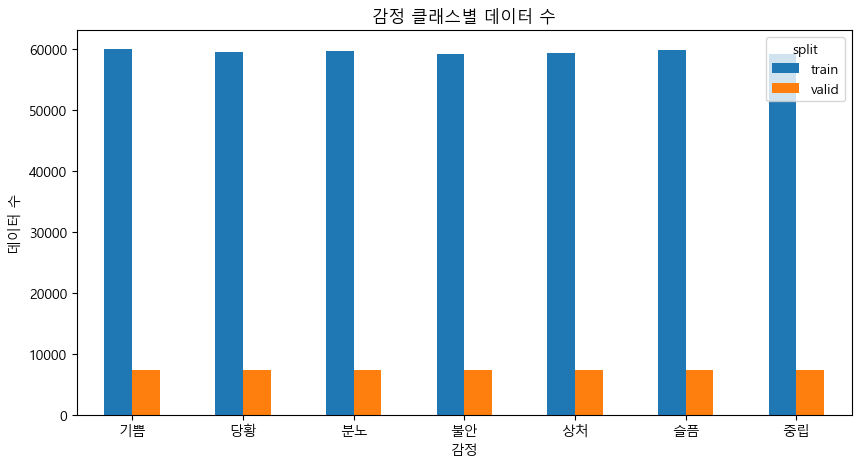

In [21]:
# 클래스별 Training/Validation 데이터 수 비교
ax = class_count_df.plot(
    kind="bar",
    figsize=(10, 5),
    title="감정 클래스별 데이터 수"
)

plt.xlabel("감정")
plt.ylabel("데이터 수")

# x축 감정명을 가로 방향으로 정렬
for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_ha("center")

plt.show()

### 확인 결과

- 7개 감정 클래스의 Training 데이터는 각 약 5.9만~6.0만 건,
  Validation 데이터는 각 약 7.4천~7.5천 건으로 확인되었다.
- 클래스별 데이터 수 차이가 크지 않아, 데이터 개수 기준으로는 심한 클래스 불균형이 보이지 않는다.
- 따라서 7개 클래스 전체를 대상으로 후속 EDA와 모델 학습을 진행할 수 있다.

## 3. 실제 사용할 Training 데이터 구성

전체 Training 원천데이터 4개 part 중
part 1과 part 2만 사용하도록 실제 학습 대상 데이터의 범위를 정리하고,
7개 감정 클래스별 데이터 수를 다시 확인한다.

In [22]:
# Training/Validation의 14개 라벨 ZIP을 하나씩 읽어서
# 라벨과 Bounding Box의 기본 구조 및 품질 확인에 필요한 정보를
# 하나의 DataFrame으로 통합한다.
label_dfs = []

for _, row in label_zip_df.iterrows():
    # 현재 처리할 라벨 ZIP 파일 경로
    zip_path = Path(row["file_path"])

    # ZIP 파일 내부 열기
    with zipfile.ZipFile(zip_path, "r") as z:

        # ZIP 내부에서 JSON 파일만 찾기
        json_names = [
            name for name in z.namelist()
            if name.lower().endswith(".json")
        ]

        # ZIP 안의 JSON 파일을 하나씩 읽기
        for json_name in json_names:
            with z.open(json_name) as f:
                data = json.load(f)

            # 라벨 및 Bounding Box의 기본 구조와 품질을 확인하기 위한 정보 추출
            temp_df = pd.DataFrame({
                "filename": [item["filename"] for item in data],
                "split": row["split"],                 # train / valid
                "source_emotion": row["emotion"],      # 원래 감정 클래스

                # 업로더 및 어노테이터 감정 라벨
                "faceExp_uploader": [
                    item["faceExp_uploader"] for item in data
                ],
                "annot_A": [
                    item["annot_A"]["faceExp"] for item in data
                ],
                "annot_B": [
                    item["annot_B"]["faceExp"] for item in data
                ],
                "annot_C": [
                    item["annot_C"]["faceExp"] for item in data
                ],

                # annot_A의 Bounding Box 좌표
                "A_minX": [
                    item["annot_A"]["boxes"]["minX"] for item in data
                ],
                "A_minY": [
                    item["annot_A"]["boxes"]["minY"] for item in data
                ],
                "A_maxX": [
                    item["annot_A"]["boxes"]["maxX"] for item in data
                ],
                "A_maxY": [
                    item["annot_A"]["boxes"]["maxY"] for item in data
                ],

                # annot_B의 Bounding Box 좌표
                "B_minX": [
                    item["annot_B"]["boxes"]["minX"] for item in data
                ],
                "B_minY": [
                    item["annot_B"]["boxes"]["minY"] for item in data
                ],
                "B_maxX": [
                    item["annot_B"]["boxes"]["maxX"] for item in data
                ],
                "B_maxY": [
                    item["annot_B"]["boxes"]["maxY"] for item in data
                ],

                # annot_C의 Bounding Box 좌표
                "C_minX": [
                    item["annot_C"]["boxes"]["minX"] for item in data
                ],
                "C_minY": [
                    item["annot_C"]["boxes"]["minY"] for item in data
                ],
                "C_maxX": [
                    item["annot_C"]["boxes"]["maxX"] for item in data
                ],
                "C_maxY": [
                    item["annot_C"]["boxes"]["maxY"] for item in data
                ]
            })

            # 각 ZIP에서 만든 DataFrame을 리스트에 저장
            label_dfs.append(temp_df)

# 14개 라벨 ZIP에서 만든 DataFrame을 하나로 합치기
full_label_df = pd.concat(
    label_dfs,
    ignore_index=True
)

# 전체 데이터 수와 앞부분 확인
print("전체 라벨 데이터 수:", len(full_label_df))
full_label_df.head()

전체 라벨 데이터 수: 469293


,filename,split,source_emotion,faceExp_uploader,annot_A,annot_B,annot_C,A_minX,A_minY,A_maxX,A_maxY,B_minX,B_minY,B_maxX,B_maxY,C_minX,C_minY,C_maxX,C_maxY
0,dd99b4f896bcc238d52bc84321602614d8897215bde8cd...,valid,기쁨,기쁨,기쁨,기쁨,기쁨,1312.193014,509.912084,2135.794044,1657.890821,1295.838386,502.981011,2162.640686,1682.454511,1308.159772,526.391933,2122.577310,1666.484985
1,9e7bac24f25feb3db4a759b4c2b409f28f7ff3f669713c...,valid,기쁨,기쁨,기쁨,기쁨,기쁨,862.790966,609.281631,1741.000366,1738.021531,859.328966,612.220631,1743.465366,1733.985531,862.464966,616.933631,1738.874366,1744.582531
2,d457724868d30d15df5f1d6b67c262d87a064c1f9309aa...,valid,기쁨,기쁨,기쁨,기쁨,기쁨,1098.872100,283.913020,1660.852000,1063.169700,1113.657672,321.104536,1646.066428,1044.709891,1093.341364,297.743203,1660.824785,1063.218845
3,21ee461934c5f88f24993d031484c617fb911a03ead847...,valid,기쁨,기쁨,기쁨,기쁨,기쁨,1365.342700,546.415470,2099.085000,1508.069800,1346.016384,581.847049,2079.758684,1543.501379,1365.342700,546.637551,2099.085000,1556.512113
4,1c4190dff43fb38b2f88320665a6d094ce633815248c7c...,valid,기쁨,기쁨,기쁨,기쁨,기쁨,848.821170,596.689500,1559.547100,1651.615400,836.759880,568.709662,1547.483607,1667.532846,837.780302,596.765979,1548.504535,1673.612431


In [23]:
# annot_A/B/C가 모두 같은 감정으로 판정했는지 확인
full_label_df["annot_all_agree"] = (
    (full_label_df["annot_A"] == full_label_df["annot_B"]) &
    (full_label_df["annot_B"] == full_label_df["annot_C"])
)

# 완전 일치 / 불일치 건수 확인
full_label_df["annot_all_agree"].value_counts()

annot_all_agree
True     240555
False    228738
Name: count, dtype: int64

In [24]:
# 세 어노테이터가 완전히 동일하게 판정한 비율
agree_rate = full_label_df["annot_all_agree"].mean() * 100

print(f"세 어노테이터 완전 일치율: {agree_rate:.2f}%")

세 어노테이터 완전 일치율: 51.26%


In [25]:
# 원래 감정 클래스별 annot_A/B/C 완전 일치율
agreement_by_emotion = (
    full_label_df
    .groupby("source_emotion")["annot_all_agree"]
    .agg(["count", "sum", "mean"])
)

agreement_by_emotion["agree_percent"] = (
    agreement_by_emotion["mean"] * 100
).round(2)

agreement_by_emotion[
    ["count", "sum", "agree_percent"]
]

,count,sum,agree_percent
source_emotion,,,
기쁨,67602,62513,92.47
당황,67097,34597,51.56
분노,67157,34321,51.11
불안,66669,14474,21.71
상처,66812,13421,20.09
슬픔,67320,32171,47.79
중립,66636,49058,73.62


### 확인 결과

- 세 어노테이터가 완전히 동일한 감정을 선택한 비율은 51.26%였다.
- 2명 이상이 같은 감정을 선택한 다수결 성립률은 86.32%로 확인되었다.
- 다수결이 성립한 데이터 중 업로더 감정과 다수결 라벨의 일치율은 78.30%였다.
- 감정별 다수결 없음 비율은 기쁨 0.80%, 중립 2.90%로 낮았고,
  불안 26.63%, 상처 28.04%로 상대적으로 높았다.
- 감정별 라벨 안정성에는 차이가 있으나, 데이터 다양성을 유지하기 위해 7개 클래스 전체를 활용한다.
- 학습 데이터는 각 Training part에서 약 50~60%를 균형 있게 샘플링하고,
  다수결 여부는 데이터 품질을 확인하기 위한 보조 지표로 활용한다.

## 3. 실제 사용할 Training 데이터 구성

전체 Training 원천데이터 4개 part 중 TRAIN_01과 TRAIN_02를 사용하도록
실제 학습 대상 이미지 목록을 구성한다.

원천 ZIP 내부의 이미지 파일명을 기준으로 라벨 데이터와 매칭하고,
7개 감정 클래스별 실제 사용 데이터 수를 확인한다.

#### 3-1. TRAIN_01, TRAIN_02 원천 ZIP만 선택

In [26]:
# Training 원천데이터 중 TRAIN_01, TRAIN_02 ZIP만 선택
selected_source_zip_df = zip_df[
    (zip_df["data_type"] == "source") &
    (zip_df["split"] == "train") &
    (zip_df["file_name"].str.contains(r"TRAIN_0[12]", regex=True))
].copy()

# 선택된 ZIP 개수 확인
print("선택된 원천 ZIP 수:", len(selected_source_zip_df))

selected_source_zip_df[
    ["emotion", "file_name"]
].sort_values(["emotion", "file_name"])

선택된 원천 ZIP 수: 14


,emotion,file_name
9,기쁨,[원천]EMOIMG_기쁨_TRAIN_01.zip
10,기쁨,[원천]EMOIMG_기쁨_TRAIN_02.zip
13,당황,[원천]EMOIMG_당황_TRAIN_01.zip
14,당황,[원천]EMOIMG_당황_TRAIN_02.zip
17,분노,[원천]EMOIMG_분노_TRAIN_01.zip
18,분노,[원천]EMOIMG_분노_TRAIN_02.zip
21,불안,[원천]EMOIMG_불안_TRAIN_01.zip
22,불안,[원천]EMOIMG_불안_TRAIN_02.zip
25,상처,[원천]EMOIMG_상처_TRAIN_01.zip
26,상처,[원천]EMOIMG_상처_TRAIN_02.zip


#### 3-2. 14개 ZIP 내부 이미지 파일명 수집

In [27]:
# ZIP 내부에서 깨진 한글 파일명을 복원하는 함수
def fix_zip_filename(name):
    try:
        return name.encode("cp437").decode("cp949")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return name

In [28]:
# TRAIN_01, TRAIN_02 ZIP 내부 이미지 정보를 저장할 리스트
selected_image_rows = []

# 이미지 파일 확장자
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

for _, row in selected_source_zip_df.iterrows():

    # 현재 처리 중인 원천 ZIP 파일 경로
    zip_path = Path(row["file_path"])

    # 현재 part 구분
    if "TRAIN_01" in row["file_name"]:
        part = "TRAIN_01"
    elif "TRAIN_02" in row["file_name"]:
        part = "TRAIN_02"
    else:
        part = "unknown"

    # ZIP 내부 파일 목록 확인
    with zipfile.ZipFile(zip_path, "r") as z:

        for member in z.namelist():

            # 이미지 파일만 선택
            if member.lower().endswith(image_extensions):

                # 깨진 한글 파일명/경로 복원
                fixed_member = fix_zip_filename(member)

                # 실제 이미지 파일명만 추출
                filename = (
                    fixed_member
                    .replace("\\", "/")
                    .split("/")[-1]
                )

                selected_image_rows.append({
                    "filename": filename,
                    "source_emotion": row["emotion"],
                    "part": part
                })

# DataFrame으로 변환
selected_image_df = pd.DataFrame(selected_image_rows)

print(
    "TRAIN_01 + TRAIN_02 이미지 수:",
    len(selected_image_df)
)

selected_image_df.head()

TRAIN_01 + TRAIN_02 이미지 수: 223578


,filename,source_emotion,part
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,기쁨,TRAIN_01
1,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,기쁨,TRAIN_01
2,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,기쁨,TRAIN_01
3,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,기쁨,TRAIN_01
4,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,기쁨,TRAIN_01


In [29]:
# 첫 번째 이미지 파일명을 repr()로 출력하여
# 숨은 문자나 깨진 인코딩이 남아 있는지 확인
print(repr(selected_image_df["filename"].iloc[0]))

'006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_기쁨_공공시설&종교&의료시설_20210130213913-001-001.jpg'


#### 3-3. 클래스별·part별 이미지 수 확인

In [30]:
# 감정 클래스별 TRAIN_01 / TRAIN_02 이미지 수 확인
part_count_df = pd.crosstab(
    selected_image_df["source_emotion"],
    selected_image_df["part"]
)

# 클래스별 전체 이미지 수 추가
part_count_df["total"] = part_count_df.sum(axis=1)

part_count_df

part,TRAIN_01,TRAIN_02,total
source_emotion,,,
기쁨,16072,15914,31986
당황,16170,15924,32094
분노,16234,15880,32114
불안,16133,15913,32046
상처,16023,15506,31529
슬픔,15874,15804,31678
중립,16197,15934,32131


#### 3-4. 원천 이미지와 라벨 데이터 매칭

In [31]:
# Training 라벨 데이터만 선택
train_label_df = full_label_df[
    full_label_df["split"] == "train"
].copy()

# 실제 사용할 원천 이미지와 라벨 데이터 매칭
selected_label_df = train_label_df.merge(
    selected_image_df,
    on=["filename", "source_emotion"],
    how="inner"
)

# 매칭된 데이터 수 확인
print("선택된 학습 라벨 데이터 수:", len(selected_label_df))

selected_label_df.head()

선택된 학습 라벨 데이터 수: 223578


,filename,split,source_emotion,faceExp_uploader,annot_A,annot_B,annot_C,A_minX,A_minY,A_maxX,...,B_minX,B_minY,B_maxX,B_maxY,C_minX,C_minY,C_maxX,C_maxY,annot_all_agree,part
0,5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf5...,train,기쁨,기쁨,기쁨,기쁨,기쁨,1187.4949,579.22235,1912.2253,...,1206.363702,579.177798,1912.348109,1572.152259,1183.841448,596.943466,1890.909447,1567.448627,True,TRAIN_01
1,92e7098109470430238876b447f55a978adf237c93b438...,train,기쁨,기쁨,기쁨,기쁨,기쁨,779.0316,803.33070,1574.1073,...,799.668169,879.985530,1588.884987,1799.845603,796.769054,934.838923,1574.186440,1797.309659,True,TRAIN_02
2,5a30dc193e2c6144184968043c00773270b111a23a3c83...,train,기쁨,기쁨,기쁨,기쁨,기쁨,1004.1328,231.63310,1821.2323,...,1004.132800,231.633100,1821.232300,1336.683500,1003.919952,324.077343,1781.668362,1337.051757,True,TRAIN_01
3,29b5343b8eca7460aea95cd18db40b015a58ec4db64b71...,train,기쁨,기쁨,기쁨,기쁨,기쁨,1868.0542,530.67320,2712.7075,...,1931.287634,551.882502,2713.101973,1545.456502,1868.054200,530.673200,2712.707500,1524.247200,True,TRAIN_02
4,4e91bb1317ff7616b99cadf3cafaf8dab49bc6985a0367...,train,기쁨,기쁨,기쁨,기쁨,기쁨,1119.3428,305.10977,1749.1846,...,1064.809046,331.380853,1789.396413,1226.330383,1119.342800,305.237652,1749.184600,1232.135797,True,TRAIN_01


In [32]:
# 원천 이미지 대비 라벨 매칭률 확인
match_rate = (
    len(selected_label_df)
    / len(selected_image_df)
    * 100
)

print(f"라벨 매칭률: {match_rate:.2f}%")

라벨 매칭률: 100.00%


In [36]:
# 라벨이 매칭되지 않은 원천 이미지 수 확인
unmatched_count = len(selected_image_df) - len(selected_label_df)

print("라벨 미매칭 이미지 수:", unmatched_count)

라벨 미매칭 이미지 수: 0


- TRAIN_01과 TRAIN_02의 원천 이미지 223,578건을 라벨 데이터와 매칭한 결과,
  모든 이미지가 라벨 정보와 연결되어 매칭률 100%로 확인되었다.

#### 3-5. 실제 사용할 7개 클래스 분포 확인

In [37]:
# 실제 사용할 Training 데이터의 클래스별 개수 확인
selected_class_count = (
    selected_label_df["source_emotion"]
    .value_counts()
    .reindex(emotions)
)

selected_class_count

source_emotion
기쁨    31986
당황    32094
분노    32114
불안    32046
상처    31529
슬픔    31678
중립    32131
Name: count, dtype: int64

In [38]:
# 실제 사용할 Training 데이터의 전체 개수 확인
print(
    "실제 사용할 Training 데이터 총 수:",
    len(selected_label_df)
)

실제 사용할 Training 데이터 총 수: 223578


### 확인 결과

- Training 원천데이터 중 TRAIN_01과 TRAIN_02를 선택한 결과 총 223,578개의 이미지가 확인되었다.
- 원천 이미지와 라벨 데이터를 매칭한 결과 223,578건이 모두 연결되어 라벨 매칭률은 100%였으며, 미매칭 이미지는 없었다.
- 7개 감정 클래스는 각 약 3.1만~3.2만 건으로 구성되어 있어 클래스 간 데이터 수 차이가 크지 않았다.
- 따라서 TRAIN_01과 TRAIN_02만 사용하더라도 7개 감정 클래스를 비교적 균형 있게 구성할 수 있음을 확인하였다.

## 4. 선택 데이터 기본 품질 확인

TRAIN_01과 TRAIN_02에서 선택한 실제 학습 대상 데이터에 대해
중복 여부, 주요 라벨의 결측 여부, 클래스별 데이터 구성을 확인한다.

이 단계에서는 특정 모델이나 전처리 방식을 가정하지 않고,
학습에 사용할 데이터 자체의 기본 품질만 점검한다.

In [39]:
# 동일한 이미지 파일명이 중복으로 존재하는지 확인
duplicate_count = selected_label_df["filename"].duplicated().sum()

print("중복 filename 수:", duplicate_count)

중복 filename 수: 0


In [40]:
# 학습에 참고할 주요 라벨 컬럼의 결측치 확인
label_columns = [
    "filename",
    "source_emotion",
    "faceExp_uploader",
    "annot_A",
    "annot_B",
    "annot_C"
]

selected_label_df[label_columns].isnull().sum()

filename            0
source_emotion      0
faceExp_uploader    0
annot_A             0
annot_B             0
annot_C             0
dtype: int64

In [41]:
# TRAIN_01 / TRAIN_02별 데이터 수 확인
selected_label_df["part"].value_counts()

part
TRAIN_01    112703
TRAIN_02    110875
Name: count, dtype: int64

### 확인 결과

- 선택한 학습 데이터 223,578건에서 중복된 filename은 확인되지 않았다.
- filename, source_emotion, faceExp_uploader, annot_A, annot_B, annot_C 컬럼의 결측치는 모두 0건으로 확인되었다.
- TRAIN_01은 112,703건, TRAIN_02는 110,875건으로 두 part의 데이터 수 차이도 크지 않았다.
- 따라서 선택한 TRAIN_01과 TRAIN_02 데이터는 중복 및 주요 라벨 결측 문제 없이 기본적인 데이터 품질이 양호한 것으로 확인되었다.

## 5. 이미지 기본 상태 확인

선택한 TRAIN_01과 TRAIN_02 이미지 중 일부를 직접 확인하여
이미지가 정상적으로 열리는지, 이미지 크기와 채널 형태가 어떠한지 확인한다.

이 단계에서는 아직 resize, 흑백 변환, 얼굴 crop 등
구체적인 전처리 방식은 결정하지 않는다.

#### 5-1. 이미지 위치 정보 추가

In [42]:
# 확인할 이미지 1개 선택
sample_row = selected_image_df.iloc[0]

sample_filename = sample_row["filename"]
sample_emotion = sample_row["source_emotion"]
sample_part = sample_row["part"]

print("파일명:", sample_filename)
print("감정:", sample_emotion)
print("part:", sample_part)

파일명: 006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9b0bfcbe540b292247d_여_20_기쁨_공공시설&종교&의료시설_20210130213913-001-001.jpg
감정: 기쁨
part: TRAIN_01


### 5-2. 이미지 1장 정상적으로 열리는지 확인

In [43]:
# 선택한 이미지가 들어 있는 원천 ZIP 찾기
sample_zip_row = selected_source_zip_df[
    (selected_source_zip_df["emotion"] == sample_emotion) &
    (selected_source_zip_df["file_name"].str.contains(sample_part))
].iloc[0]

sample_zip_path = Path(sample_zip_row["file_path"])

# ZIP 내부에서 선택한 이미지 파일 찾기
sample_member = None

with zipfile.ZipFile(sample_zip_path, "r") as z:
    for member in z.namelist():

        # 깨진 한글 파일명 복원
        fixed_member = fix_zip_filename(member)

        # 실제 파일명만 추출
        filename = (
            fixed_member
            .replace("\\", "/")
            .split("/")[-1]
        )

        # 선택한 파일명과 일치하는 이미지 찾기
        if filename == sample_filename:
            sample_member = member
            break

print("ZIP 파일:", sample_zip_path.name)
print("이미지 찾음:", sample_member is not None)

ZIP 파일: [원천]EMOIMG_기쁨_TRAIN_01.zip
이미지 찾음: True


### 5-3. 이미지 크기와 채널 확인 및 화면 출력

In [47]:
import numpy as np
import cv2
import zipfile
import matplotlib.pyplot as plt

from pathlib import Path

In [48]:
# ZIP 내부의 선택한 이미지 읽기
with zipfile.ZipFile(sample_zip_path, "r") as z:
    image_bytes = z.read(sample_member)

# 이미지 바이트를 OpenCV에서 읽을 수 있는 배열로 변환
image_array = np.frombuffer(image_bytes, dtype=np.uint8)

# 컬러 이미지로 디코딩
sample_image = cv2.imdecode(
    image_array,
    cv2.IMREAD_COLOR
)

# 이미지 기본 정보 확인
print("이미지 크기:", sample_image.shape)
print("데이터 타입:", sample_image.dtype)

이미지 크기: (2268, 4032, 3)
데이터 타입: uint8


### 확인 결과

- 선택한 이미지는 정상적으로 로드되었으며 색상 및 이미지 손상 문제는 확인되지 않았다.
- 확인한 이미지의 크기는 4032×2268이며 3채널 컬러 이미지로 확인되었다.
- 얼굴이 명확하게 포함되어 있으나 배경 영역도 함께 포함되어 있어, 이후 전처리 단계에서 얼굴 영역 활용 여부를 검토할 필요가 있다.

#### 5-4. 여러 이미지의 크기와 형태 확인

In [51]:
# 선택한 이미지 1장을 ZIP에서 찾아 읽는 함수
def load_selected_image(row):

    # 감정 클래스와 part에 맞는 ZIP 찾기
    zip_row = selected_source_zip_df[
        (selected_source_zip_df["emotion"] == row["source_emotion"]) &
        (selected_source_zip_df["file_name"].str.contains(row["part"]))
    ].iloc[0]

    zip_path = Path(zip_row["file_path"])

    # ZIP 내부에서 같은 파일명 찾기
    with zipfile.ZipFile(zip_path, "r") as z:
        for member in z.namelist():

            fixed_member = fix_zip_filename(member)

            filename = (
                fixed_member
                .replace("\\", "/")
                .split("/")[-1]
            )

            if filename == row["filename"]:

                # 이미지 데이터를 읽고 OpenCV 이미지로 변환
                image_bytes = z.read(member)
                image_array = np.frombuffer(
                    image_bytes,
                    dtype=np.uint8
                )

                return cv2.imdecode(
                    image_array,
                    cv2.IMREAD_COLOR
                )

    return None

In [52]:
# 앞에서부터 이미지 10개 선택
sample_rows = selected_image_df.head(10)

# 이미지 크기 확인
for i, (_, row) in enumerate(
    sample_rows.iterrows(),
    start=1
):
    image = load_selected_image(row)

    print(
        f"{i}번 이미지 크기:",
        image.shape
    )

1번 이미지 크기: (2268, 4032, 3)
2번 이미지 크기: (2268, 4032, 3)
3번 이미지 크기: (2268, 4032, 3)
4번 이미지 크기: (2268, 4032, 3)
5번 이미지 크기: (2268, 4032, 3)
6번 이미지 크기: (2268, 4032, 3)
7번 이미지 크기: (2268, 4032, 3)
8번 이미지 크기: (2268, 4032, 3)
9번 이미지 크기: (2268, 4032, 3)
10번 이미지 크기: (2268, 4032, 3)


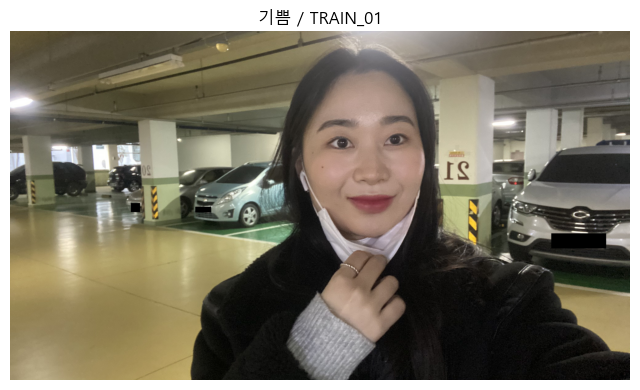

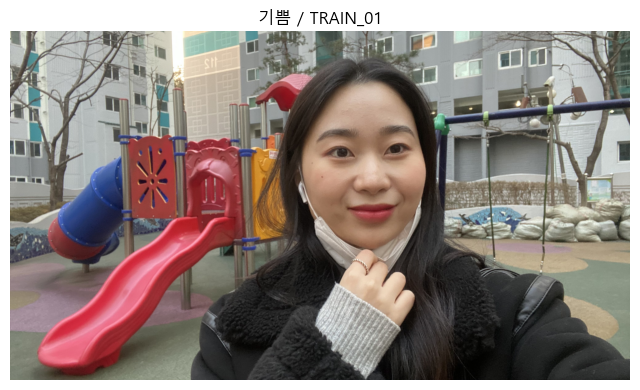

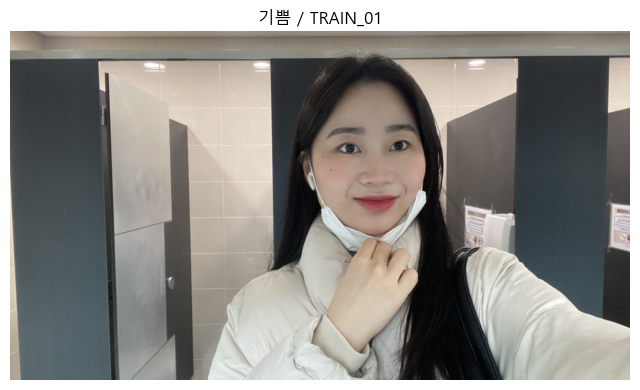

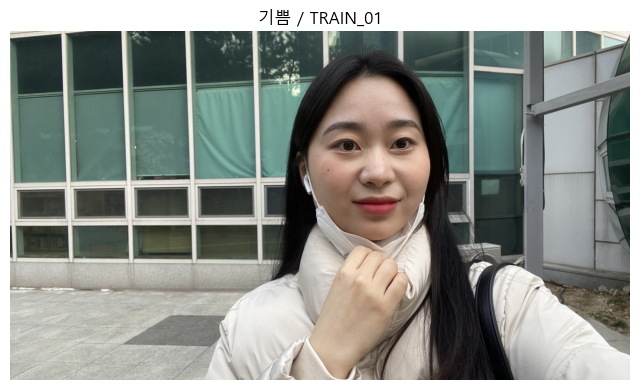

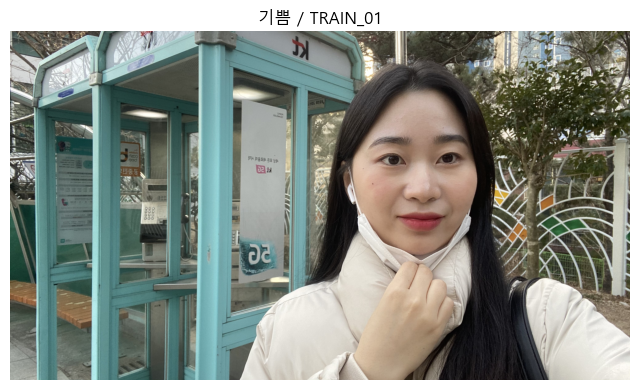

In [53]:
# 앞의 이미지 5장 화면에 출력
for _, row in sample_rows.head(5).iterrows():

    image = load_selected_image(row)

    # OpenCV의 BGR 이미지를 RGB로 변환
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(
        f"{row['source_emotion']} / {row['part']}"
    )
    plt.show()

#### 5-5. 클래스별 이미지 간단 확인

In [54]:
# 7개 감정 클래스에서 이미지 1장씩 선택
class_sample_rows = (
    selected_image_df
    .groupby("source_emotion", group_keys=False)
    .head(1)
)

# 클래스별 이미지 크기 확인
for _, row in class_sample_rows.iterrows():

    image = load_selected_image(row)

    print(
        f"{row['source_emotion']}: "
        f"{image.shape}"
    )

기쁨: (2268, 4032, 3)
당황: (2268, 4032, 3)
분노: (2268, 4032, 3)
불안: (2268, 4032, 3)
상처: (2268, 4032, 3)
슬픔: (2268, 4032, 3)
중립: (2268, 4032, 3)


### 확인 결과

- 선택한 원본 이미지는 정상적으로 로드되었으며 3채널 컬러 이미지로 확인되었다.
- 7개 감정 클래스에서 각각 1장씩 확인한 결과, 모든 샘플의 이미지 크기는 2268×4032로 동일하였다.
- 실제 이미지를 확인한 결과 얼굴과 함께 주변 배경 영역도 포함되어 있었다.
- 현재 단계에서는 resize, 흑백 변환, 얼굴 crop 등의 구체적인 전처리 방법은 결정하지 않았다.

## 6. 전처리 방향 검토

앞선 EDA에서 확인한 이미지와 라벨 구조를 바탕으로
모델 학습 전에 검토할 전처리 항목을 확인한다.


### 6-1. Bounding Box 정보 확인

In [55]:
# 확인 중인 이미지의 라벨 정보 찾기
sample_label = selected_label_df[
    selected_label_df["filename"] == sample_filename
].iloc[0]

# 어노테이터 A, B, C의 Bounding Box 좌표 확인
bbox_columns = [
    "A_minX", "A_minY", "A_maxX", "A_maxY",
    "B_minX", "B_minY", "B_maxX", "B_maxY",
    "C_minX", "C_minY", "C_maxX", "C_maxY"
]

sample_label[bbox_columns]

A_minX      1898.7701
A_minY       260.2512
A_maxX      2698.8945
A_maxY      1364.5962
B_minX    1909.640968
B_minY     249.256617
B_maxX    2695.314771
B_maxY    1335.496459
C_minX    1907.092141
C_minY      251.91699
C_maxX    2707.216541
C_maxY     1356.26199
Name: 5375, dtype: object

### 6-2. 이미지 위에 Bounding Box 표시

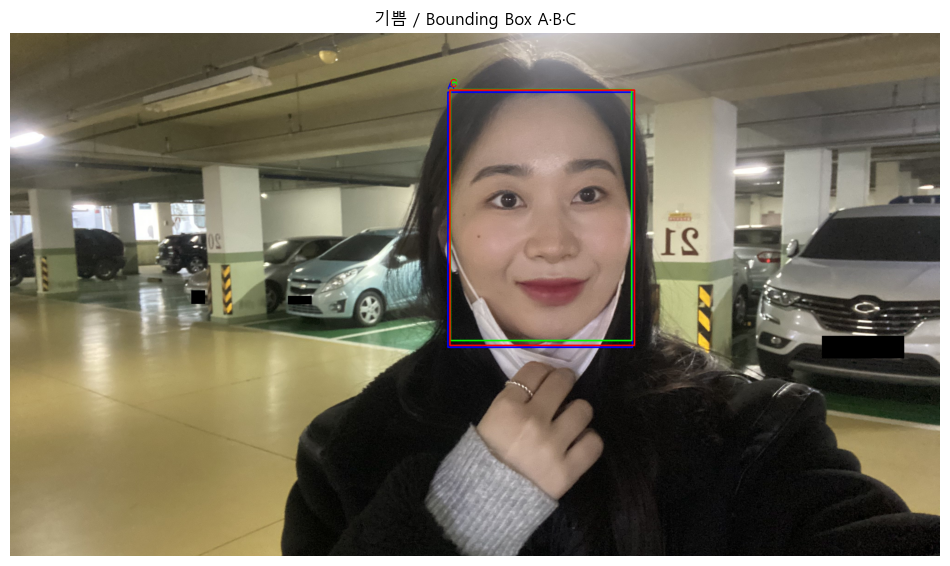

In [57]:
# 원본 이미지를 복사해서 Bounding Box 표시용 이미지 생성
bbox_image = sample_image.copy()

# 어노테이터별 Bounding Box 좌표와 표시 색상
bbox_info = {
    "A": (
        sample_label["A_minX"],
        sample_label["A_minY"],
        sample_label["A_maxX"],
        sample_label["A_maxY"],
        (255, 0, 0)    # 파랑
    ),
    "B": (
        sample_label["B_minX"],
        sample_label["B_minY"],
        sample_label["B_maxX"],
        sample_label["B_maxY"],
        (0, 255, 0)    # 초록
    ),
    "C": (
        sample_label["C_minX"],
        sample_label["C_minY"],
        sample_label["C_maxX"],
        sample_label["C_maxY"],
        (0, 0, 255)    # 빨강
    )
}

# A, B, C Bounding Box를 각각 다른 색으로 표시
for label, (min_x, min_y, max_x, max_y, color) in bbox_info.items():

    pt1 = (int(min_x), int(min_y))
    pt2 = (int(max_x), int(max_y))

    # 박스 두께를 조금 크게 설정
    cv2.rectangle(
        bbox_image,
        pt1,
        pt2,
        color,
        5
    )

    # 어노테이터 이름 표시
    cv2.putText(
        bbox_image,
        label,
        (pt1[0], pt1[1] - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        color,
        4
    )

# matplotlib 출력용 BGR → RGB 변환
bbox_image_rgb = cv2.cvtColor(
    bbox_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))
plt.imshow(bbox_image_rgb)
plt.axis("off")
plt.title(f"{sample_emotion} / Bounding Box A·B·C")
plt.show()

### 확인 결과

- 어노테이터 A, B, C의 Bounding Box를 서로 다른 색으로 표시한 결과,
  세 박스가 거의 동일한 위치에 겹쳐 있는 것을 확인하였다.
- 확인한 샘플에서는 세 Bounding Box 모두 얼굴 영역을 정상적으로 포함하였다.
- 어노테이터별 좌표에는 약간의 차이가 있었지만 큰 위치 차이는 확인되지 않았다.
- 현재 단계에서는 특정 Bounding Box를 선택하거나 통합하지 않고,
  제공된 Bounding Box의 상태만 확인하였다.

#### 6-3. 여러 감정 클래스의 Bounding Box 확인

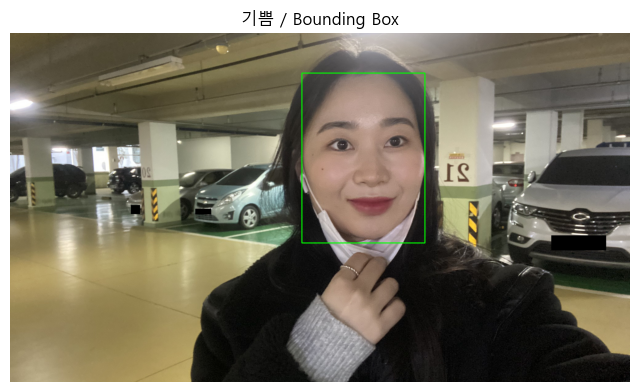

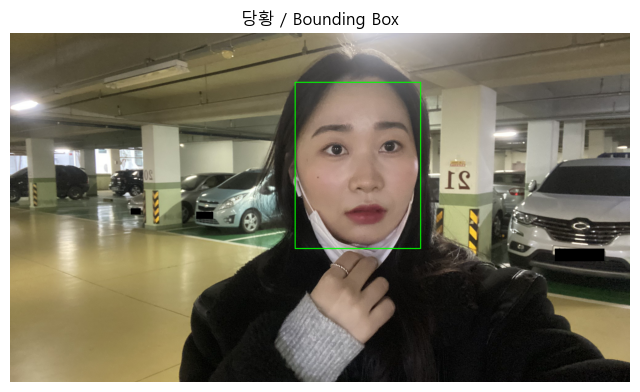

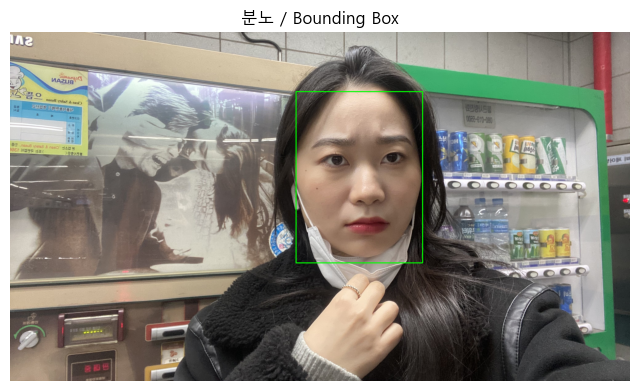

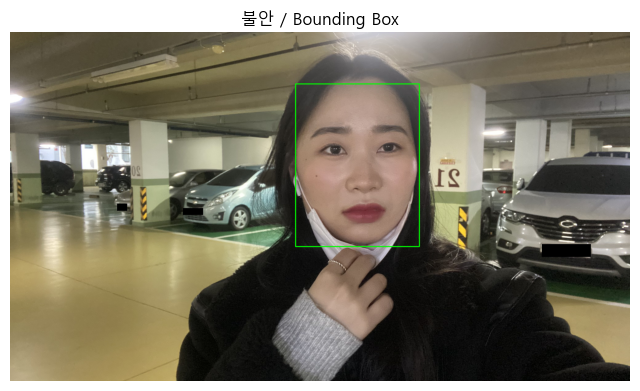

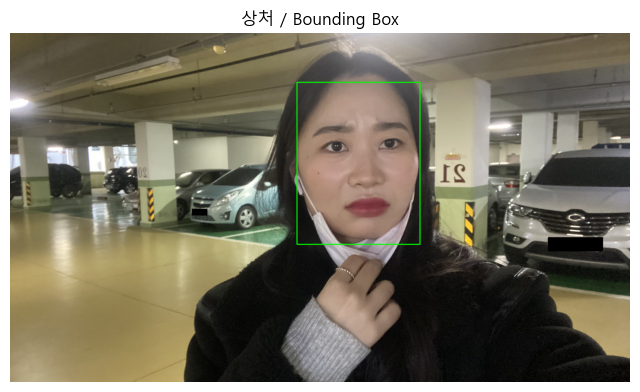

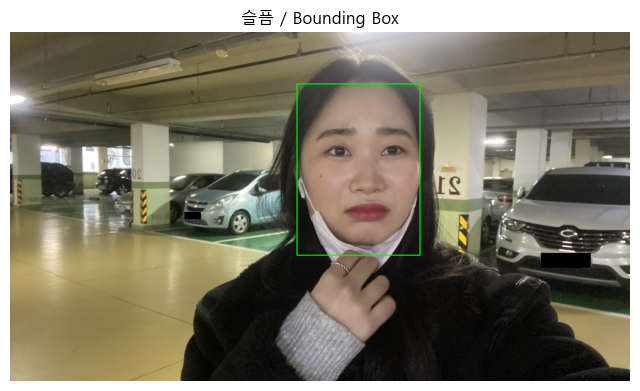

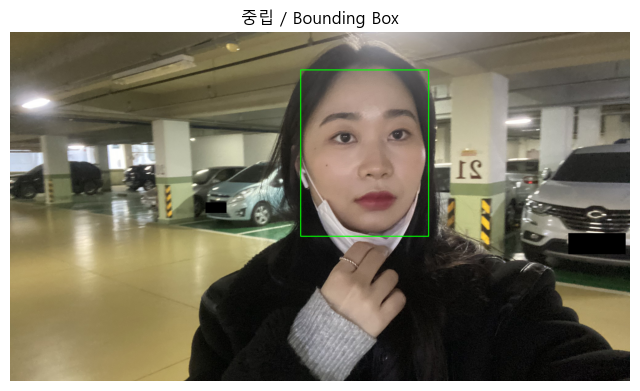

In [58]:
# 7개 감정 클래스에서 이미지 1장씩 선택
class_sample_rows = (
    selected_image_df
    .groupby("source_emotion", group_keys=False)
    .head(1)
)

for _, row in class_sample_rows.iterrows():

    # 이미지 불러오기
    image = load_selected_image(row)

    # 해당 이미지의 라벨 정보 찾기
    label_row = selected_label_df[
        selected_label_df["filename"] == row["filename"]
    ].iloc[0]

    # 어노테이터 A의 Bounding Box 좌표
    pt1 = (
        int(label_row["A_minX"]),
        int(label_row["A_minY"])
    )

    pt2 = (
        int(label_row["A_maxX"]),
        int(label_row["A_maxY"])
    )

    # 원본 이미지 복사 후 Bounding Box 표시
    bbox_image = image.copy()

    cv2.rectangle(
        bbox_image,
        pt1,
        pt2,
        (0, 255, 0),
        5
    )

    # matplotlib 출력용 BGR → RGB 변환
    bbox_image_rgb = cv2.cvtColor(
        bbox_image,
        cv2.COLOR_BGR2RGB
    )

    # 이미지 출력
    plt.figure(figsize=(8, 5))
    plt.imshow(bbox_image_rgb)
    plt.axis("off")
    plt.title(f"{row['source_emotion']} / Bounding Box")
    plt.show()

### 전처리 검토 결과

- 확인한 샘플에서 제공된 Bounding Box는 얼굴 영역을 정상적으로 포함하고 있었다.
- 한 샘플에서 어노테이터 A, B, C의 Bounding Box를 비교한 결과 세 박스는 거의 비슷한 위치에 나타났다.
- 7개 감정 클래스에서 각각 샘플 이미지를 확인한 결과, 확인한 범위에서는 얼굴 영역이 정상적으로 지정되어 있었다.
- 원본 이미지에는 얼굴 외의 배경 영역이 많이 포함되어 있어 이후 학습 단계에서 Bounding Box를 활용한 얼굴 영역 사용 여부를 검토할 필요가 있다.
- 원본 이미지의 해상도가 4032×2268로 크기 때문에 모델 학습 시 이미지 크기 조정이 필요할 가능성이 높다.
- 구체적인 resize 크기, 흑백 변환 여부, Bounding Box 활용 방식은 이후 모델 선정 및 학습 실험 과정에서 결정한다.